# 🤖 Notebook 04 — LLM Retention Engine
### Telecom Churn Intelligence + LLM Retention Engine

**Goal:** Use Groq LLM to generate personalized retention messages for high-risk customers.

**LLM:** Groq API (llama-3.3-70b-versatile) — free and fast

**Input:** `cell2cell_high_risk.csv` — high risk customers from Notebook 03

**Output:** `cell2cell_retention_messages.csv` — personalized retention message per customer

---

## Step 1 — Install and Import Libraries

In [1]:
!pip install groq -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from groq import Groq

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ Libraries imported')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 3.7 MB/s eta 0:00:00
✅ Libraries imported


## Step 2 — Load Groq API Key from Kaggle Secrets

In [2]:
from kaggle_secrets import UserSecretsClient
from groq import Groq

# Get secret
user_secrets = UserSecretsClient()
api_key = user_secrets.get_secret("GROQ_API_KEY")

# Connect to Groq
client = Groq(api_key=api_key)

# Test connection
test = client.chat.completions.create(
    model='llama-3.3-70b-versatile',
    messages=[{'role': 'user', 'content': 'Say: connected successfully'}],
    max_tokens=20
)
print(test.choices[0].message.content)
print('✅ Groq API connected')


Connected successfully.
✅ Groq API connected


## Step 3 — Load High Risk Customers

In [3]:
# Load high risk customers saved at end of Notebook 03
# ── STEP 3 — Complete code ─────────────────────────────────────

# Cell 1 — Load data
df = pd.read_csv('/kaggle/input/notebooks/mayssanefzi/notebokk03/cell2cell_high_risk.csv')
print(f'High risk customers loaded: {len(df):,}')
print(f'Segment distribution:')
print(df['Segment_Label'].value_counts())

# Cell 2 — Sample 50 customers
df_sample = df.groupby('Segment_Label', group_keys=False).apply(
    lambda x: x.nlargest(min(20, len(x)), 'Churn_Probability')
).head(50).reset_index(drop=True)
print(f'\n✅ df_sample created: {len(df_sample)} customers')
print(df_sample['Segment_Label'].value_counts())

# Cell 3 — Make churn reasons readable
reason_map = {
    'MadeCallToRetentionTeam_Yes'  : 'Already contacted retention team — still at risk',
    'MonthlyMinutes'               : 'High monthly usage exceeding plan limits',
    'CustomerCareCalls'            : 'Frequent customer support calls — dissatisfied',
    'RetentionCalls'               : 'Multiple retention attempts failed',
    'OverageMinutes'               : 'Constantly exceeding plan minute limits',
    'DroppedCalls'                 : 'Poor network quality — frequent dropped calls',
    'Care_Call_Rate'               : 'High support call rate relative to tenure',
    'Overage_Ratio'                : 'High overage usage relative to plan',
    'Drop_Rate'                    : 'High call drop rate',
    'Retention_Success'            : 'Low retention offer acceptance rate',
    'Revenue_per_Minute'           : 'Low revenue efficiency',
    'MonthsInService'              : 'Long-tenure customer showing signs of disengagement',
    'PercChangeMinutes'            : 'Significant drop in usage compared to previous month',
    'CurrentEquipmentDays'         : 'Using outdated equipment for too long — needs upgrade',
    'HandsetPrice'                 : 'High-end device user expecting premium service',
    'IncomeGroup'                  : 'Income profile mismatch with current plan',
    'AgeHH1'                       : 'Age profile suggests different service needs',
    'MonthlyRevenue'               : 'Revenue declining — customer reducing usage',
    'TotalRecurringCharge'         : 'Plan cost too high relative to usage',
    'DroppedBlockedCalls'          : 'Repeated network failures causing frustration',
 }

reason_map['UniqueSubs'] = 'Multiple subscriptions suggesting potential plan consolidation'

df_sample['Top_Churn_Reason'] = df_sample['Top_Churn_Reason'].replace(reason_map)
print('\n✅ All churn reasons human-readable')
print(df_sample['Top_Churn_Reason'].value_counts())
print()
print('Sample customer ready for LLM:')
print(df_sample[['Segment_Label', 'Churn_Probability',
                  'Top_Churn_Reason', 'MonthlyRevenue',
                  'MonthsInService', 'CustomerCareCalls']].head(3).to_string())

High risk customers loaded: 10,607
Segment distribution:
Segment_Label
Heavy Users At Risk                8330
Churning Dissatisfied Customers    1267
Low Engagement Customers           1010
Name: count, dtype: int64

✅ df_sample created: 50 customers
Segment_Label
Churning Dissatisfied Customers    20
Heavy Users At Risk                20
Low Engagement Customers           10
Name: count, dtype: int64

✅ All churn reasons human-readable
Top_Churn_Reason
High monthly usage exceeding plan limits                          24
Long-tenure customer showing signs of disengagement               15
Significant drop in usage compared to previous month               5
Already contacted retention team — still at risk                   4
Using outdated equipment for too long — needs upgrade              1
Multiple subscriptions suggesting potential plan consolidation     1
Name: count, dtype: int64

Sample customer ready for LLM:
                     Segment_Label  Churn_Probability                

## Step 4 — Write the Prompt Function
This is the most important step — the quality of your prompt determines the quality of the LLM output.

In [4]:
def build_prompt(customer):
    """
    Builds a structured prompt for each customer.
    The LLM reads this and generates a personalized retention strategy.
    """

    # Segment-specific context to guide the LLM
    segment_context = {
        'Heavy Users At Risk': (
            'high-usage customer who exceeds their plan limits often '
            'and experiences frequent dropped calls. '
            'They need a better plan and network quality assurance.'
        ),
        'Churning Dissatisfied Customers': (
            'long-tenure customer who has already been contacted by '
            'the retention team but remains at very high churn risk. '
            'They need a strong, personalized offer — standard offers have not worked.'
        ),
        'Low Engagement Customers': (
            'low-usage customer on a basic plan who is disengaging. '
            'They need re-engagement — remind them of value or offer a cheaper plan.'
        )
    }

    seg = customer.get('Segment_Label', 'Unknown Segment')
    context = segment_context.get(seg, 'telecom customer at risk of leaving.')

    churn_prob  = customer.get('Churn_Probability', 0)
    tenure      = customer.get('MonthsInService', 'unknown')
    monthly_rev = customer.get('MonthlyRevenue', 'unknown')
    care_calls  = customer.get('CustomerCareCalls', 0)
    overage     = customer.get('OverageMinutes', 0)
    ret_calls   = customer.get('RetentionCalls', 0)
    top_reason  = customer.get('Top_Churn_Reason', 'unknown')

    prompt = f"""You are a senior retention specialist at a telecom company .
Your job is to write a short, personalized retention strategy for a customer at risk of leaving.

CUSTOMER PROFILE:
- Segment         : {seg}
- Profile         : This is a {context}
- Churn Risk      : {churn_prob*100:.1f}% probability of leaving
- Tenure          : {tenure} months with the company
- Monthly Revenue : ${monthly_rev:.2f}/month
- Support Calls   : {care_calls:.0f} calls to customer care this month
- Overage Minutes : {overage:.0f} minutes over plan limit
- Retention Calls : {ret_calls:.0f} times retention team already called
- Top Churn Driver: {top_reason}

Write a retention strategy with EXACTLY these 4 sections:
1. SITUATION (1 sentence): summarize why this customer is at risk
2. OFFER (1 sentence): one specific retention offer tailored to their profile
3. MESSAGE (2 sentences): what the agent should say when calling this customer
4. URGENCY (1 sentence): how soon to contact them and why

Be specific, human, and concise. Do not use generic phrases."""

    return prompt


# Test the prompt on one customer
sample_customer = df_sample.iloc[0]
print('=== SAMPLE PROMPT ===')
print(build_prompt(sample_customer))

=== SAMPLE PROMPT ===
You are a senior retention specialist at a telecom company .
Your job is to write a short, personalized retention strategy for a customer at risk of leaving.

CUSTOMER PROFILE:
- Segment         : Churning Dissatisfied Customers
- Profile         : This is a long-tenure customer who has already been contacted by the retention team but remains at very high churn risk. They need a strong, personalized offer — standard offers have not worked.
- Churn Risk      : 87.0% probability of leaving
- Tenure          : 11.0 months with the company
- Monthly Revenue : $141.92/month
- Support Calls   : 0 calls to customer care this month
- Overage Minutes : 261 minutes over plan limit
- Retention Calls : 0 times retention team already called
- Top Churn Driver: Long-tenure customer showing signs of disengagement

Write a retention strategy with EXACTLY these 4 sections:
1. SITUATION (1 sentence): summarize why this customer is at risk
2. OFFER (1 sentence): one specific retenti

## Step 5 — Call the Groq API for Each Customer

In [5]:
def generate_retention_message(customer, client, model='llama-3.3-70b-versatile'):
    """
    Calls Groq API with the customer prompt.
    Returns the LLM-generated retention strategy.
    """
    try:
        response = client.chat.completions.create(
            model=model,
            messages=[
                {
                    'role': 'system',
                    'content': (
                        'You are a telecom retention specialist. '
                        'You write concise, actionable, personalized retention strategies. '
                        'Always follow the exact format requested.'
                    )
                },
                {
                    'role': 'user',
                    'content': build_prompt(customer)
                }
            ],
            max_tokens=300,
            temperature=0.7   # some creativity but not too random
        )
        return response.choices[0].message.content.strip()

    except Exception as e:
        return f'ERROR: {str(e)}'


# Test on one customer before running on all
print('Testing on first customer...')
print()
test_response = generate_retention_message(df_sample.iloc[0], client)
print('=== LLM RESPONSE ===')
print(test_response)

Testing on first customer...

=== LLM RESPONSE ===
1. SITUATION: This long-tenure customer is at risk of leaving due to disengagement, despite being a valuable customer with a high monthly revenue of $141.92, and having recently exceeded their plan limit by 261 minutes.

2. OFFER: We will offer this customer a customized plan that includes an additional 500 minutes per month, a dedicated customer care hotline, and a $20 monthly credit for the next 6 months to address their specific needs and show our commitment to their satisfaction.

3. MESSAGE: When calling this customer, the agent should express appreciation for their long-term loyalty and acknowledge the recent overage minutes, saying something like: "We've noticed you've been with us for 11 months and have recently gone over your plan limit, and we want to ensure you have the right plan to meet your needs." The agent should then present the customized offer, highlighting how it addresses the customer's specific situation and demon

In [6]:
# Run on all sampled customers
# Groq free tier: ~30 requests/minute — we add a small delay
print(f'Generating retention messages for {len(df_sample)} customers...')
print('(This will take about 2-3 minutes)')
print()

messages   = []
errors     = []
batch_size = 10

for i, (idx, customer) in enumerate(df_sample.iterrows()):
    msg = generate_retention_message(customer, client)
    messages.append(msg)

    if 'ERROR' in msg:
        errors.append(i)
        print(f'  [{i+1}/{len(df_sample)}] ❌ Error for customer {idx}')
    else:
        print(f'  [{i+1}/{len(df_sample)}] ✅ {customer["Segment_Label"]} '
              f'({customer["Churn_Probability"]*100:.0f}% risk)')

    # Pause every 10 requests to respect rate limits
    if (i + 1) % batch_size == 0:
        print(f'  Pausing 5s to respect rate limits...')
        time.sleep(5)

df_sample['Retention_Message'] = messages

print()
print(f'✅ Done — {len(messages) - len(errors)} messages generated successfully')
if errors:
    print(f'⚠️  {len(errors)} errors — check rate limits or API key')

Generating retention messages for 50 customers...
(This will take about 2-3 minutes)

  [1/50] ✅ Churning Dissatisfied Customers (87% risk)
  [2/50] ✅ Churning Dissatisfied Customers (86% risk)
  [3/50] ✅ Churning Dissatisfied Customers (85% risk)
  [4/50] ✅ Churning Dissatisfied Customers (84% risk)
  [5/50] ✅ Churning Dissatisfied Customers (83% risk)
  [6/50] ✅ Churning Dissatisfied Customers (83% risk)
  [7/50] ✅ Churning Dissatisfied Customers (83% risk)
  [8/50] ✅ Churning Dissatisfied Customers (82% risk)
  [9/50] ✅ Churning Dissatisfied Customers (81% risk)
  [10/50] ✅ Churning Dissatisfied Customers (81% risk)
  Pausing 5s to respect rate limits...
  [11/50] ✅ Churning Dissatisfied Customers (81% risk)
  [12/50] ✅ Churning Dissatisfied Customers (81% risk)
  [13/50] ✅ Churning Dissatisfied Customers (81% risk)
  [14/50] ✅ Churning Dissatisfied Customers (81% risk)
  [15/50] ✅ Churning Dissatisfied Customers (81% risk)
  [16/50] ✅ Churning Dissatisfied Customers (81% risk)
  [1

## Step 6 — Save the Results

In [7]:
# Save full results
df_sample.to_csv('cell2cell_retention_messages.csv', index=False)
print('✅ Saved: cell2cell_retention_messages.csv')
print(f'   Shape: {df_sample.shape}')
print(f'   New column: Retention_Message')
print()

# Save one clean file per segment for easy use
for seg in df_sample['Segment_Label'].unique():
    seg_df = df_sample[df_sample['Segment_Label'] == seg]
    filename = seg.lower().replace(' ', '_') + '_retention.csv'
    seg_df.to_csv(filename, index=False)
    print(f'✅ Saved: {filename} ({len(seg_df)} customers)')

✅ Saved: cell2cell_retention_messages.csv
   Shape: (50, 70)
   New column: Retention_Message

✅ Saved: churning_dissatisfied_customers_retention.csv (20 customers)
✅ Saved: heavy_users_at_risk_retention.csv (20 customers)
✅ Saved: low_engagement_customers_retention.csv (10 customers)


## Step 7 — Visualize and Read the Results

In [8]:
# Show one sample message per segment — clean readable format
print('=' * 70)
print('         SAMPLE RETENTION MESSAGES PER SEGMENT')
print('=' * 70)

for seg in df_sample['Segment_Label'].unique():
    seg_df = df_sample[df_sample['Segment_Label'] == seg]
    # Pick highest risk customer in this segment
    top_customer = seg_df.nlargest(1, 'Churn_Probability').iloc[0]

    print(f'\n🔴 SEGMENT: {seg}')
    print(f'   Churn Probability : {top_customer["Churn_Probability"]*100:.1f}%')
    print(f'   Tenure            : {top_customer["MonthsInService"]:.0f} months')
    print(f'   Monthly Revenue   : ${top_customer["MonthlyRevenue"]:.2f}')
    print(f'   Top Churn Reason  : {top_customer["Top_Churn_Reason"]}')
    print()
    print('   📋 RETENTION STRATEGY:')
    print()
    for line in top_customer['Retention_Message'].split('\n'):
        if line.strip():
            print(f'   {line}')
    print()
    print('-' * 70)

         SAMPLE RETENTION MESSAGES PER SEGMENT

🔴 SEGMENT: Churning Dissatisfied Customers
   Churn Probability : 87.0%
   Tenure            : 11 months
   Monthly Revenue   : $141.92
   Top Churn Reason  : Long-tenure customer showing signs of disengagement

   📋 RETENTION STRATEGY:

   1. SITUATION: This long-tenure customer is at risk of leaving due to disengagement, despite being a valuable customer with a monthly revenue of $141.92, and has already exceeded their plan limit by 261 minutes.
   2. OFFER: We will offer this customer a customized plan that includes an additional 500 minutes per month for the next 3 months, with a $20 credit on their next bill to offset the recent overage charges.
   3. MESSAGE: When calling this customer, the agent should express appreciation for their loyalty and acknowledge the recent overage charges, saying something like: "We value your business and want to ensure you have the right plan to meet your needs, which is why we'd like to offer you a cu

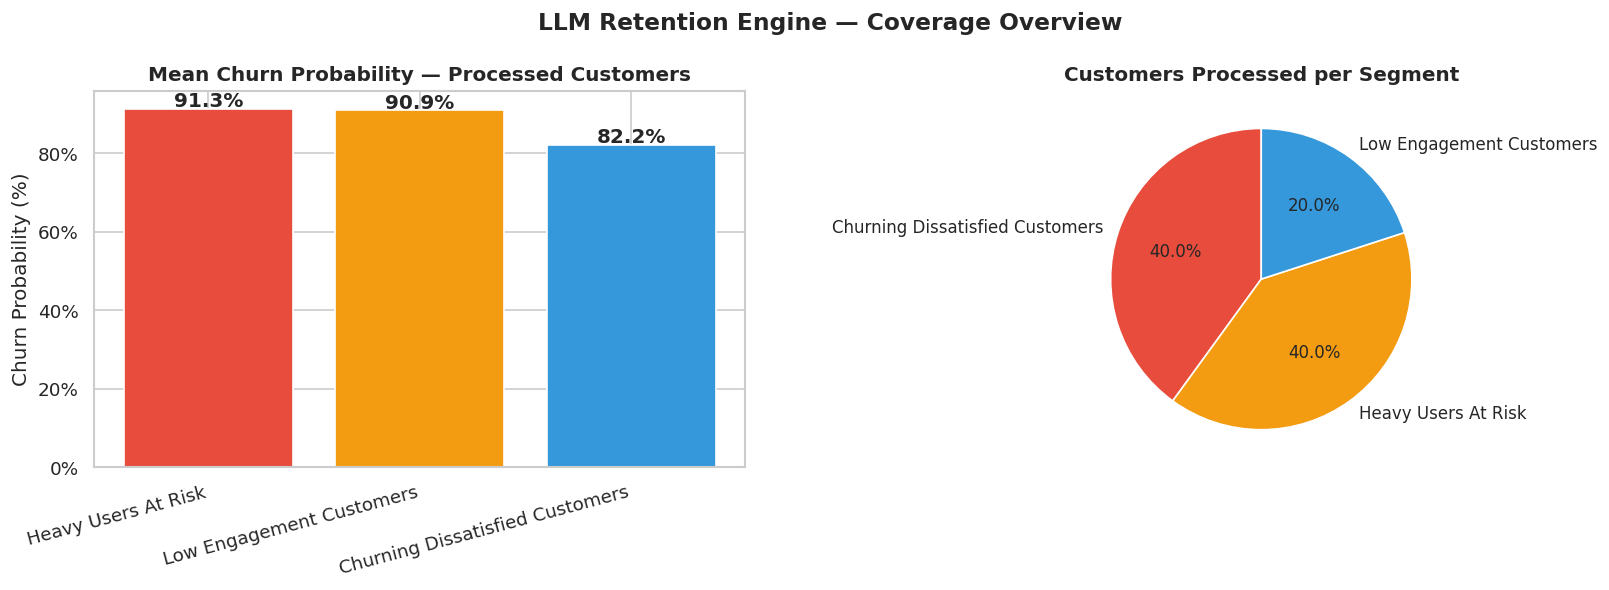

In [9]:
# Visualize churn probability distribution of processed customers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn prob by segment
seg_prob = df_sample.groupby('Segment_Label')['Churn_Probability'].mean().sort_values(ascending=False)
colors   = ['#e74c3c', '#f39c12', '#3498db']
bars = axes[0].bar(range(len(seg_prob)), seg_prob.values * 100,
                   color=colors[:len(seg_prob)], edgecolor='white')
axes[0].set_xticks(range(len(seg_prob)))
axes[0].set_xticklabels(seg_prob.index, rotation=15, ha='right')
axes[0].set_title('Mean Churn Probability — Processed Customers',
                  fontweight='bold', fontsize=12)
axes[0].set_ylabel('Churn Probability (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars, seg_prob.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val*100:.1f}%', ha='center', fontweight='bold')

# Customer count per segment
seg_count = df_sample['Segment_Label'].value_counts()
axes[1].pie(seg_count.values,
            labels=seg_count.index,
            autopct='%1.1f%%',
            colors=colors[:len(seg_count)],
            startangle=90,
            textprops={'fontsize': 10})
axes[1].set_title('Customers Processed per Segment',
                  fontweight='bold', fontsize=12)

plt.suptitle('LLM Retention Engine — Coverage Overview',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('retention_overview.png', bbox_inches='tight')
plt.show()

## Step 8 — Business Summary

In [10]:
# Business impact calculation
RETENTION_CALL_COST = 10   # DT per retention call
WIN_RATE            = 0.5  # assume 50% of contacted customers stay

n_processed        = len(df_sample)
total_call_cost    = n_processed * RETENTION_CALL_COST
avg_monthly_rev    = df_sample['MonthlyRevenue'].mean()
annual_rev_at_risk = df_sample['MonthlyRevenue'].sum() * 12
revenue_saved      = annual_rev_at_risk * WIN_RATE
roi                = revenue_saved / total_call_cost

print('=' * 65)
print('         BUSINESS IMPACT SUMMARY')
print('=' * 65)
print(f'  High risk customers processed   : {n_processed}')
print(f'  Messages generated              : {(~df_sample["Retention_Message"].str.startswith("ERROR")).sum()}')
print(f'  Cost per retention call         : {RETENTION_CALL_COST} DT')
print(f'  Total retention campaign cost   : {total_call_cost:,.0f} DT')
print(f'  Avg monthly revenue per customer: ${avg_monthly_rev:.2f}')
print(f'  Annual revenue at risk          : ${annual_rev_at_risk:,.0f}')
print(f'  Revenue saved (50% win rate)    : ${revenue_saved:,.0f}')
print(f'  ROI                             : {roi:.0f}x')
print()
print('  Per Segment:')
seg_summary = df_sample.groupby('Segment_Label').agg(
    Customers=('Churn_Probability', 'count'),
    Avg_Risk=('Churn_Probability', lambda x: f'{x.mean()*100:.1f}%'),
    Revenue_at_Risk=('MonthlyRevenue', lambda x: f'${x.sum()*12:,.0f}')
)
print(seg_summary.to_string())
print()
print('  What the LLM adds:')
print('  → Each customer gets a message tailored to their exact profile')
print('  → Retention agent knows WHAT to say before picking up the phone')
print('  → Segment-specific offers — not one generic discount for everyone')
print('=' * 65)

         BUSINESS IMPACT SUMMARY
  High risk customers processed   : 50
  Messages generated              : 50
  Cost per retention call         : 10 DT
  Total retention campaign cost   : 500 DT
  Avg monthly revenue per customer: $65.50
  Annual revenue at risk          : $39,299
  Revenue saved (50% win rate)    : $19,650
  ROI                             : 39x

  Per Segment:
                                 Customers Avg_Risk Revenue_at_Risk
Segment_Label                                                      
Churning Dissatisfied Customers         20    82.2%         $30,291
Heavy Users At Risk                     20    91.3%          $5,033
Low Engagement Customers                10    90.9%          $3,975

  What the LLM adds:
  → Each customer gets a message tailored to their exact profile
  → Retention agent knows WHAT to say before picking up the phone
  → Segment-specific offers — not one generic discount for everyone


## Conclusions

### What We Built
An end-to-end LLM-powered retention engine that:
1. Reads high-risk customers identified by XGBoost/LightGBM in Notebook 03
2. Builds a personalized prompt per customer using their profile, segment, and top churn reason
3. Calls Groq API (Llama3) to generate a 4-part retention strategy
4. Saves results ready for the retention team to use

### Why This Is Powerful
| Without this system | With this system |
|---|---|
| Agent calls with no context | Agent knows exact churn risk before calling |
| Same script for all customers | Personalized message per customer profile |
| React after customer leaves | Proactively contact before they leave |
| Generic discount offered | Specific offer matched to their pain point |

### Full Project Summary
```
Notebook 01 — EDA              → understood the data
Notebook 02 — Segmentation     → grouped 51K customers into 3 behavioral segments
Notebook 03 — Churn Prediction → predicted churn probability per customer (AUC ~0.80+)
Notebook 04 — LLM Engine       → generated personalized retention strategy per customer
```

### CV Line
> **Telecom Churn Intelligence + LLM Retention Engine** | Python, XGBoost, LightGBM, SHAP, Groq API, Kaggle
> Built an end-to-end data science project on 51K real telecom customers. Segmented customers with KMeans, predicted churn with XGBoost + LightGBM (AUC: 0.8X), explained predictions with SHAP, and integrated Groq LLM API to auto-generate personalized retention strategies per customer segment.